In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("ifood_df.csv")
data



,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014.0,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0


In [81]:
print(f"Shape of dataset: {data.shape}")

data.isnull().sum()
#Clearly there are no missing values

Shape of dataset: (2205, 39)


Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [82]:
data.info()
#There are no non-null values
#Gives info about the datatype of each column

<class 'pandas.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3          2205 non-n

In [83]:
#Stnadarizing columns names
data.columns=data.columns.str.title().str.replace(' ','_')


In [84]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Mntwines,Mntfruits,Mntmeatproducts,Mntfishproducts,Mntsweetproducts,Mntgoldprods,...,Marital_Together,Marital_Widow,Education_2N_Cycle,Education_Basic,Education_Graduation,Education_Master,Education_Phd,Mnttotal,Mntregularprods,Acceptedcmpoverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [85]:
#Including only positive only for Mnteregularprods columns
data=data[data['Mntregularprods']>0]

#Dropping a few columns that would not be needed for the analysis
data.drop(columns=['Z_Revenue','Z_Costcontact'],inplace=True, errors="ignore")




In [86]:
#Descriptive Statistics using RFM method

#How often recently they buy is given by Recency

#How much a customer spends on an average
data["Total_Purchase"]=data["Numdealspurchases"]+data["Numwebpurchases"]+data["Numcatalogpurchases"]+data["Numstorepurchases"]

data["Average_Purchase"]=data["Mnttotal"]/(data["Total_Purchase"].replace(0,1))

data[["Income","Mnttotal","Total_Purchase","Average_Purchase","Recency"]].describe()

,Income,Mnttotal,Total_Purchase,Average_Purchase,Recency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,51712.654545,563.911364,14.894545,29.910248,49.035455
std,20645.630869,576.083004,7.605781,27.422601,28.895393
min,1730.000000,4.000000,0.000000,0.466667,0.000000
25%,35335.500000,56.000000,8.000000,7.800000,24.000000
50%,51369.000000,344.500000,15.000000,20.809524,49.000000
75%,68325.000000,964.000000,21.000000,41.400210,74.000000
max,113734.000000,2491.000000,43.000000,161.923077,99.000000


**Customer Spending**

The average customer spends $563.91 in total, but the median is only $344.50, indicating that a small group of high-spending customers significantly increases the overall average.

**Purchase Frequency**

Customers make about 15 purchases on average, suggesting a reasonably active customer base.

**Transaction Value**

The average amount spent per purchase is $29.91, while some customers spend substantially more, as shown by the maximum value of $161.92.

**Customer Engagemen**

Customers' last purchases occurred about 49 days ago on average, indicating a mix of active and inactive customers.

In [87]:
features = data[["Income","Recency","Mnttotal","Total_Purchase"]]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
 
# Elbow method: try different numbers of clusters (k) and look for the
# point where adding more clusters stops meaningfully reducing inertia
inertias = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled)
    inertias.append(km.inertia_)
 
# Fit final model (k=4 commonly works well for this dataset)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data["Segment"] = kmeans.fit_predict(scaled)


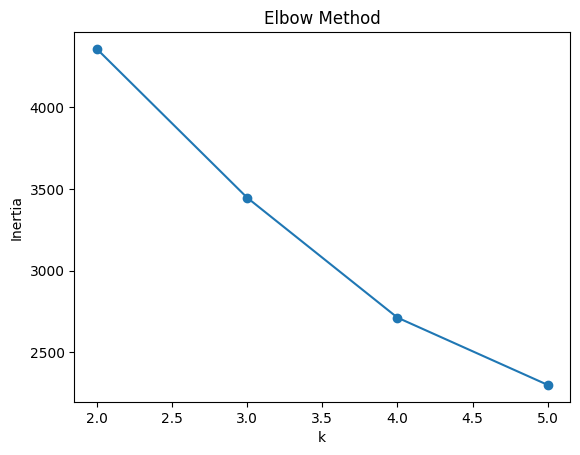

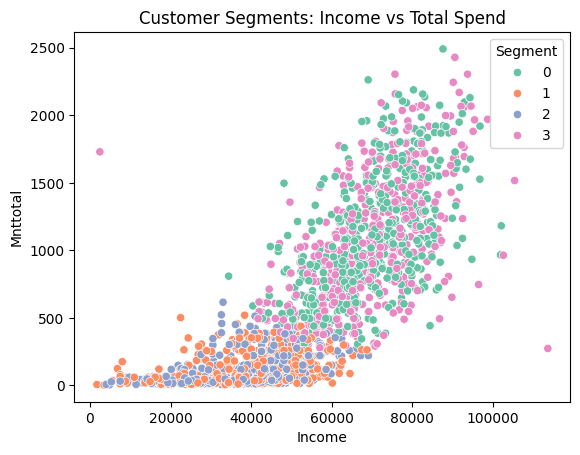

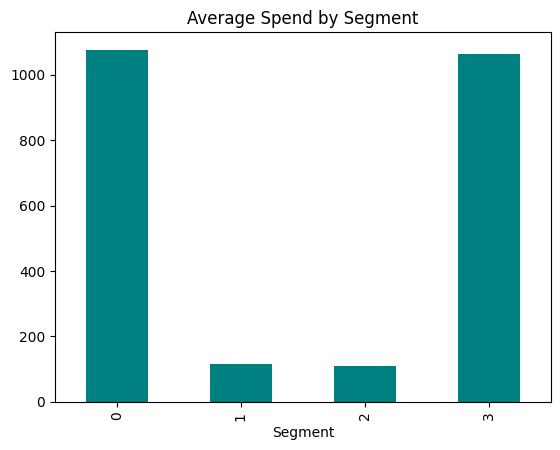

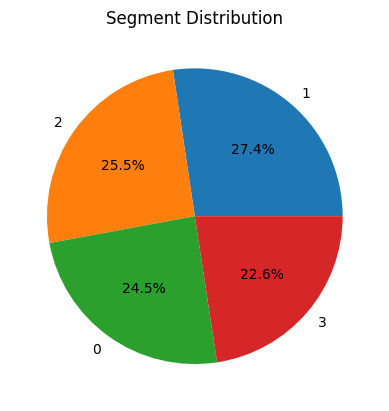

In [88]:
# Elbow plot — justifies the choice of k=4
plt.plot(range(2, 6), inertias, marker="o")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow Method")
plt.show()
 
# Scatter: Income vs Spend by segment — checks clusters are visually separable
sns.scatterplot(data=data,x="Income", y="Mnttotal", hue="Segment", palette="Set2")
plt.title("Customer Segments: Income vs Total Spend")
plt.show()
 
# Bar chart: average spend per segment — easy to compare segment value
data.groupby("Segment")["Mnttotal"].mean().plot(kind="bar", color="teal")
plt.title("Average Spend by Segment")
plt.show()
 
# Segment size distribution — shows how big/small each group is
data["Segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Segment Distribution")
plt.show()



In [89]:
data.groupby("Segment")[["Income","Recency","Mnttotal","Total_Purchase"]].mean().round(2)

,Income,Recency,Mnttotal,Total_Purchase
Segment,,,,
0,69219.35,73.06,1076.56,21.36
1,36431.04,73.10,115.61,9.12
2,35497.60,22.80,110.91,8.83
3,69572.38,23.50,1063.21,21.73


| Segment | Customer Profile | Key Characteristics | Business Insight |
|----------|----------------|---------------------|------------------|
| **0** | High Income, High Spending but Inactive | Highest income (~69k), high total spending (~1077), frequent purchases (~21), but high recency (~73 days) | These are valuable customers who have not purchased recently. They should be targeted with retention campaigns, personalized offers, and loyalty rewards to prevent churn. |
| **1** | Low Income, Low Spending and Inactive | Low income (~36k), very low spending (~116), few purchases (~9), high recency (~73 days) | This segment represents low-value and disengaged customers. Re-engagement campaigns may be attempted, but they are unlikely to generate significant revenue. |
| **2** | Low Income, Low Spending but Active | Lowest income (~35k), lowest spending (~111), few purchases (~9), low recency (~23 days) | These customers are actively engaging despite low spending. Upselling, cross-selling, and promotional offers could increase their purchase value. |
| **3** | High Income, High Spending and Active | Highest income (~70k), high total spending (~1063), most purchases (~22), low recency (~24 days) | This is the most valuable customer segment. They are active, loyal, and generate substantial revenue. Businesses should prioritize retention and premium loyalty programs for this group. |


### Key Insights

- Segments **0** and **3** are the highest-value customer groups, having both high income and high spending patterns.
- Segment **3** is the most desirable segment as customers are actively purchasing and contribute significantly to revenue.
- Segment **0** appears to be an **at-risk VIP segment**, as customers spend heavily but have not purchased recently.
- Segments **1** and **2** consist of lower-income, lower-spending customers.
- Segment **2** is more promising than Segment **1** because customers remain actively engaged despite lower spending levels.
- Marketing efforts should focus on retaining Segment **3**, reactivating Segment **0**, and increasing basket size for Segment **2**.

Recency is inverse to engagement (lower recency = more recently active customer). That's why Segment 3 is stronger than Segment 0 even though their spending is almost the same.

## Business Recommendations

### 1. Retain High-Value Active Customers (Segment 3)
- Introduce premium loyalty programs and exclusive rewards.
- Offer personalized product recommendations based on purchase history.
- Provide early access to new products and special discounts.
- Focus on maintaining customer satisfaction to maximize lifetime value.

### 2. Re-Engage High-Value Inactive Customers (Segment 0)
- Launch targeted email and SMS campaigns with personalized offers.
- Provide limited-time discounts to encourage repeat purchases.
- Send reminders about loyalty points, rewards, or abandoned interests.
- Conduct surveys to understand reasons for reduced engagement.

### 3. Increase Spending of Active Low-Value Customers (Segment 2)
- Offer product bundles and volume discounts.
- Recommend complementary products based on previous purchases.

### 4. Improve Engagement of Low-Value Inactive Customers (Segment 1)
- Run promotional campaigns to bring customers back.
- Offer introductory discounts and seasonal deals.
- Use targeted advertisements to increase brand awareness.
- Monitor campaign effectiveness to avoid excessive marketing costs.

### 5. Implement Segment-Based Marketing
- Develop separate marketing strategies for each customer segment.
- Allocate more resources to high-value segments that generate the most revenue.
- Use personalized communication instead of one-size-fits-all campaigns.

### 6. Build a Customer Retention Strategy
- Continuously monitor customer recency and purchase behavior.
- Identify customers moving from Segment 3 to Segment 0 and intervene early.
- Track customer lifetime value (CLV) to prioritize retention efforts.

### Expected Business Impact
- Increased customer retention among high-value customers.
- Higher revenue through targeted upselling and cross-selling.
- Reduced customer churn through proactive engagement campaigns.
- More efficient marketing spend by focusing on the right customer segments.